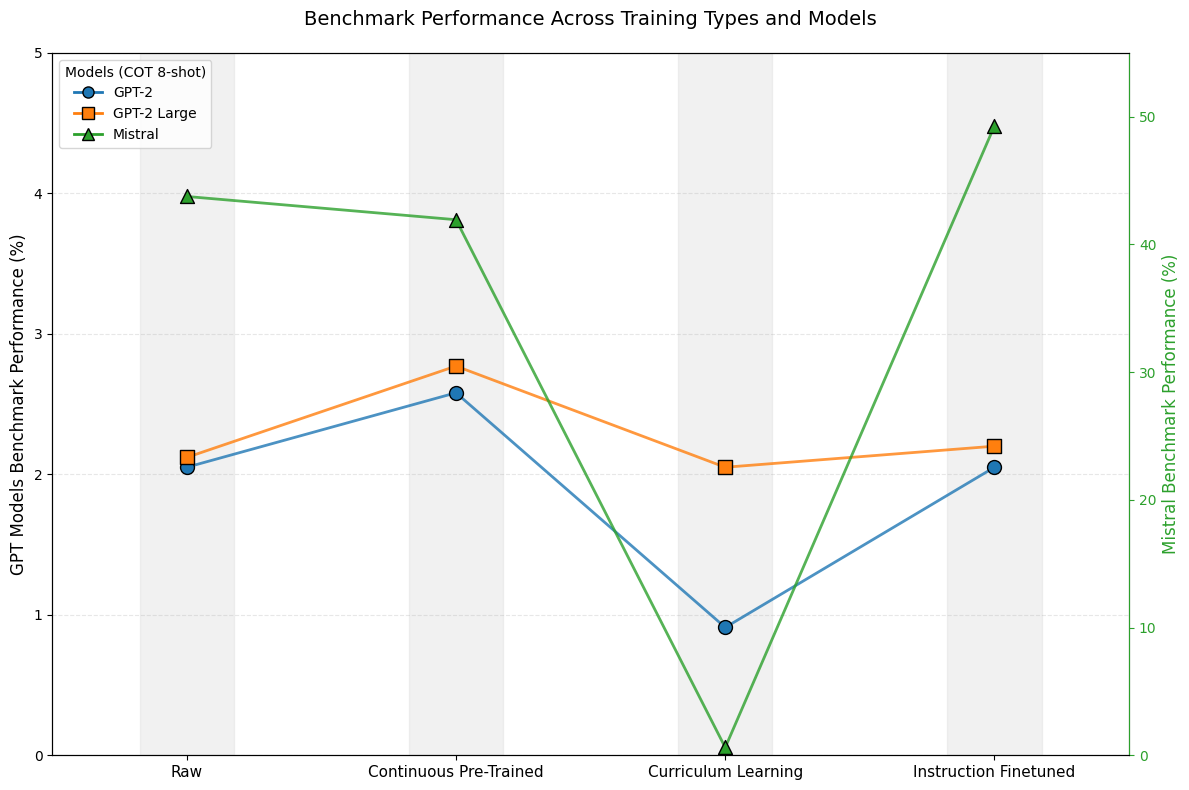

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors and markers for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area
fig, ax_left = plt.subplots(figsize=(12, 8))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=0.3, zorder=0))

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get COT value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(cot)

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Draw connecting lines if multiple points
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)

# Set y-axis limits with some padding
ax_left.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(0, 55)    # Mistral scale (0-55%)

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(list(training_positions.keys()), fontsize=11, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Set y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=12, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=12, color=right_color)

# Create custom legend with both line and marker
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend
ax_left.legend(handles=model_legend, 
              loc='upper left', fontsize=10, title="Models (COT 8-shot)")

# Title
plt.title('Benchmark Performance Across Training Types and Models', fontsize=14, pad=20)

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Remove the "Best" annotation as requested

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig('benchmark_performance_single_plot.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

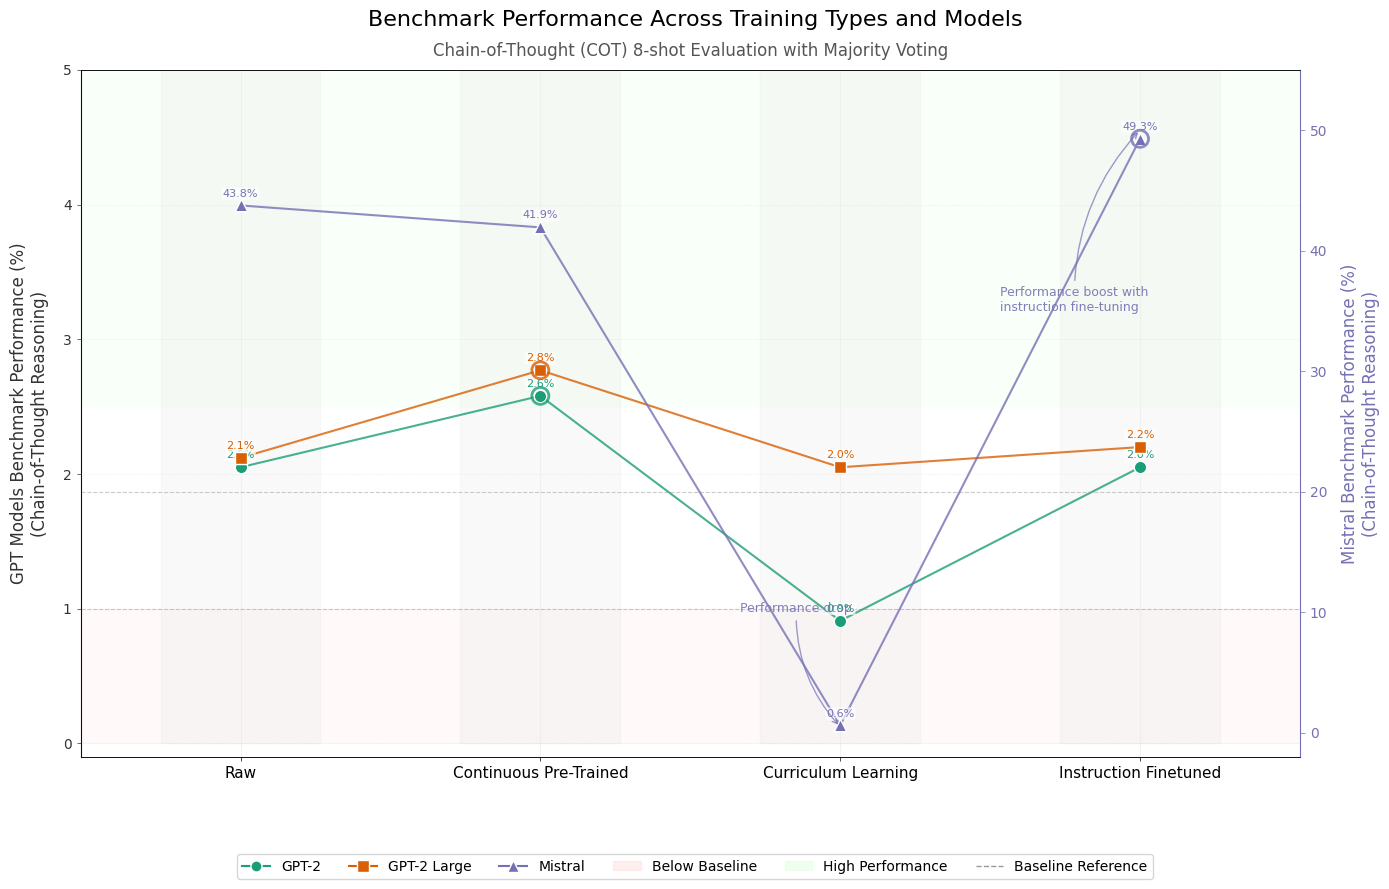

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

# Set colorblind-friendly palette (using a recommended set from ColorBrewer)
plt.rcParams['axes.prop_cycle'] = plt.cycler('color', 
                                             ['#1b9e77',  # teal
                                              '#d95f02',  # orange
                                              '#7570b3',  # purple/blue
                                              '#e7298a',  # pink
                                              '#66a61e',  # green
                                              '#e6ab02']) # yellow

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis with wider spacing
training_positions = {training: i*1.5+1 for i, training in enumerate(training_types)}

# Define colors and markers with a colorblind-friendly palette
model_colors = {
    'GPT-2': '#1b9e77',        # teal
    'GPT-2 Large': '#d95f02',  # orange
    'Mistral': '#7570b3'       # purple/blue
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area
fig, ax_left = plt.subplots(figsize=(14, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = '#333333'      # Dark gray for GPT models
right_color = '#7570b3'     # Purple/blue for Mistral

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color, width=0.5)
ax_left.spines['left'].set_color(left_color)
ax_left.spines['left'].set_linewidth(0.8)
ax_right.tick_params(axis='y', colors=right_color, width=0.5)
ax_right.spines['right'].set_color(right_color)
ax_right.spines['right'].set_linewidth(0.8)

# Clean up other spines
for spine in ['top', 'bottom', 'right']:
    ax_left.spines[spine].set_linewidth(0.5)
for spine in ['top', 'bottom', 'left']:
    ax_right.spines[spine].set_linewidth(0.5)

# Create vertical reference lines between training types
for x_pos in training_positions.values():
    ax_left.axvline(x=x_pos, color='lightgray', linestyle='-', linewidth=0.8, alpha=0.3, zorder=0)

# Create wider training "bars" instead of lines
bar_width = 0.8  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position with more subtle coloring
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='#f0f0f0', alpha=0.4, zorder=0))

# Add baseline reference
ax_left.axhline(y=1.0, color='#999999', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)
ax_right.axhline(y=20.0, color='#999999', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get COT value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(cot)
            model_data[model]['training'].append(training)

# Find highest performance points for each model
highest_points = {}
for model, data in model_data.items():
    if data['y']:  # Check if list is not empty
        max_idx = np.argmax(data['y'])
        highest_points[model] = (data['x'][max_idx], data['y'][max_idx])

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw connecting lines with reduced thickness
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=1.5, alpha=0.8, zorder=2)
    
    # Draw points with smaller size but higher contrast
    scatter = ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=80, zorder=3, edgecolors='white', linewidth=1)
    
    # Add numeric labels near data points
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        if model == 'Mistral':
            ax.annotate(f"{y:.1f}%", 
                     xy=(x, y), 
                     xytext=(0, 5), 
                     textcoords='offset points',
                     ha='center', va='bottom',
                     fontsize=8, color=model_colors[model],
                     bbox=dict(boxstyle="round,pad=0.1", fc='white', ec="none", alpha=0.7))
        else:
            ax.annotate(f"{y:.1f}%", 
                     xy=(x, y), 
                     xytext=(0, 5), 
                     textcoords='offset points',
                     ha='center', va='bottom',
                     fontsize=8, color=model_colors[model],
                     bbox=dict(boxstyle="round,pad=0.1", fc='white', ec="none", alpha=0.7))

# Highlight the highest-performing model points
for model, (x, y) in highest_points.items():
    if model == 'Mistral':
        ax_right.scatter([x], [y], s=150, facecolors='none', edgecolors=model_colors[model], 
                      linewidth=2, alpha=0.8, zorder=4)
    else:
        ax_left.scatter([x], [y], s=150, facecolors='none', edgecolors=model_colors[model], 
                      linewidth=2, alpha=0.8, zorder=4)

# Add performance threshold regions with subtle shading
ax_left.axhspan(0, 1, alpha=0.1, color='#ffcccc', zorder=0)  # Poor performance zone
ax_left.axhspan(2.5, 5, alpha=0.1, color='#ccffcc', zorder=0)  # Good performance zone

# Set y-axis limits with some padding
ax_left.set_ylim(-0.1, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(-2, 55)    # Mistral scale (-2-55%)

# Have fewer ticks on the axes for cleaner look
ax_left.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax_right.yaxis.set_major_locator(MaxNLocator(nbins=6))

# Set x-axis labels and improve tick appearance
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(list(training_positions.keys()), fontsize=11, rotation=0, ha='center')
ax_left.set_xlim(min(training_positions.values())-0.8, max(training_positions.values())+0.8)
ax_left.tick_params(axis='x', which='both', width=0.5, length=3)
ax_left.tick_params(axis='y', which='both', width=0.5, length=3)

# Set more descriptive y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)\n(Chain-of-Thought Reasoning)', 
                  fontsize=12, color=left_color, labelpad=10)
ax_right.set_ylabel('Mistral Benchmark Performance (%)\n(Chain-of-Thought Reasoning)', 
                   fontsize=12, color=right_color, labelpad=10)

# Create custom legend with both line and marker, positioned at the bottom
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=1.5,
                      markerfacecolor=model_colors[model], markeredgecolor='white'))

# Add performance zones to legend
poor_patch = mpatches.Patch(color='#ffcccc', alpha=0.3, label='Below Baseline')
good_patch = mpatches.Patch(color='#ccffcc', alpha=0.3, label='High Performance')
baseline_line = Line2D([0], [0], color='#999999', lw=1, linestyle='--', label='Baseline Reference')

# Group legend items
gpt_legend = model_legend[:2]  # GPT models
mistral_legend = [model_legend[2]]  # Mistral
context_legend = [poor_patch, good_patch, baseline_line]  # Context items

# Create a figure-wide legend at the bottom
fig.legend(handles=gpt_legend + mistral_legend + context_legend,
          loc='upper center', bbox_to_anchor=(0.5, 0.05),
          fancybox=True, shadow=False, ncol=6, fontsize=10)

# Add more comprehensive title and subtitle
plt.suptitle('Benchmark Performance Across Training Types and Models', 
             fontsize=16, y=0.98)
plt.title('Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', 
          fontsize=12, pad=10, color='#555555')

# Improve grid appearance
ax_left.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.3)

# Add subtle annotations to explain key trends
# For Mistral drop in Curriculum Learning
ax_right.annotate('Performance drop', 
                xy=(training_positions['Curriculum Learning'], 0.5), 
                xytext=(training_positions['Curriculum Learning']-0.5, 10),
                arrowprops=dict(arrowstyle='->',
                                color=model_colors['Mistral'],
                                alpha=0.7,
                                connectionstyle="arc3,rad=.2"),
                fontsize=9, color=model_colors['Mistral'], alpha=0.9)

# For dramatic performance boost with instruction fine-tuning
ax_right.annotate('Performance boost with\ninstruction fine-tuning', 
                xy=(training_positions['Instruction Finetuned'], 50), 
                xytext=(training_positions['Instruction Finetuned']-0.7, 35),
                arrowprops=dict(arrowstyle='->',
                                color=model_colors['Mistral'],
                                alpha=0.7,
                                connectionstyle="arc3,rad=-.2"),
                fontsize=9, color=model_colors['Mistral'], alpha=0.9)

# Adjust figure layout with more bottom space for legend
fig.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Save the plot
plt.savefig('benchmark_performance_comprehensive.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

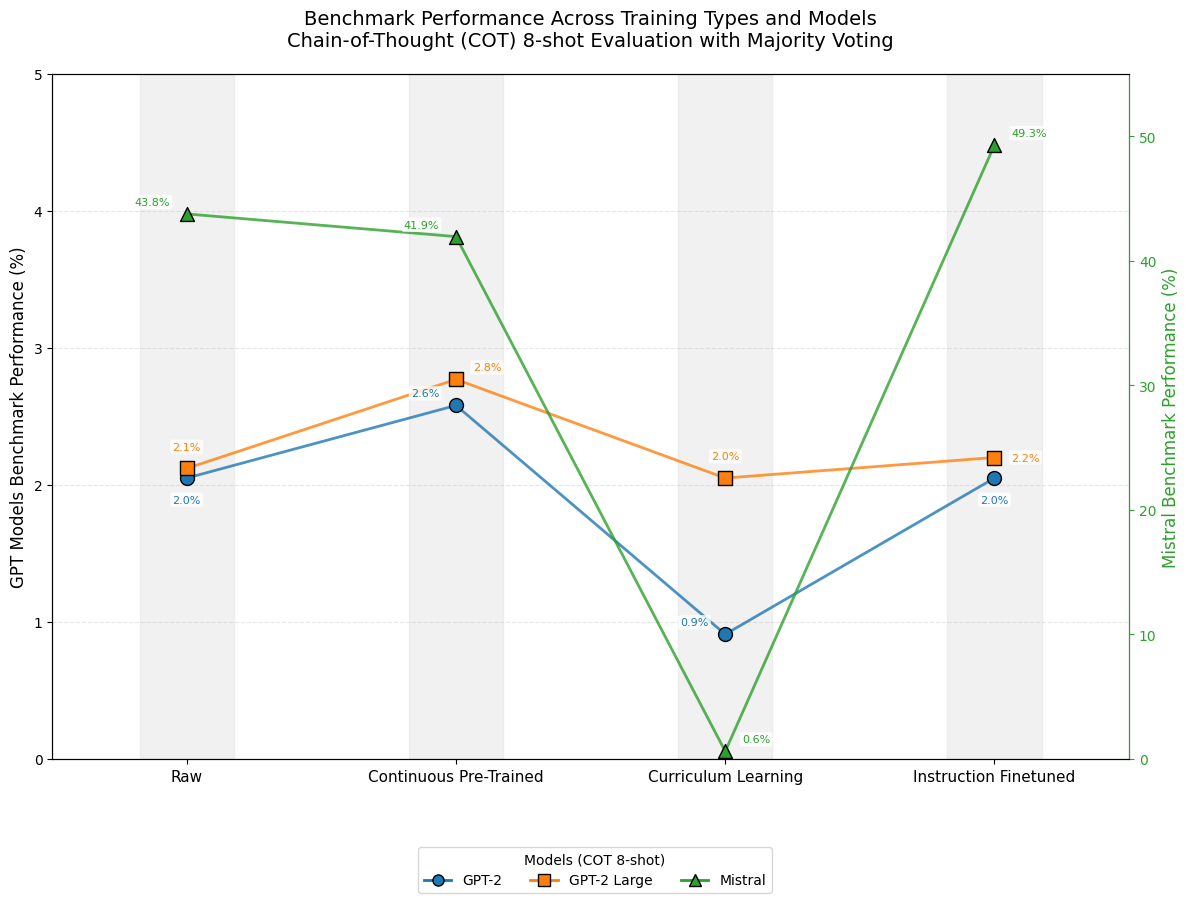

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('', engine='openpyxl')

# Ensure the columns are numeric
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors and markers for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area - slightly taller for legend space at bottom
fig, ax_left = plt.subplots(figsize=(12, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0), bar_width, 5, 
                              color='lightgray', alpha=0.3, zorder=0))

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get COT value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(cot)
            model_data[model]['training'].append(training)

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    # Use predefined positions to avoid overlaps
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # to avoid overlaps without using external libraries
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=8,
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Set y-axis limits with some padding
ax_left.set_ylim(0, 5)      # GPT models scale (0-5%)
ax_right.set_ylim(0, 55)    # Mistral scale (0-55%)

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(list(training_positions.keys()), fontsize=11, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Set y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=12, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=12, color=right_color)

# Create custom legend with both line and marker
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=8, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom of the plot
fig.legend(handles=model_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.06),
          ncol=len(models), fontsize=10, title="Models (COT 8-shot)")

# Add title - combine into a single title since subtitle is showing as main title
plt.title('Benchmark Performance Across Training Types and Models\n' + 
          'Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', 
          fontsize=14, pad=20)

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout - make more room at the bottom for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Save the plot
plt.savefig('benchmark_performance_final.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

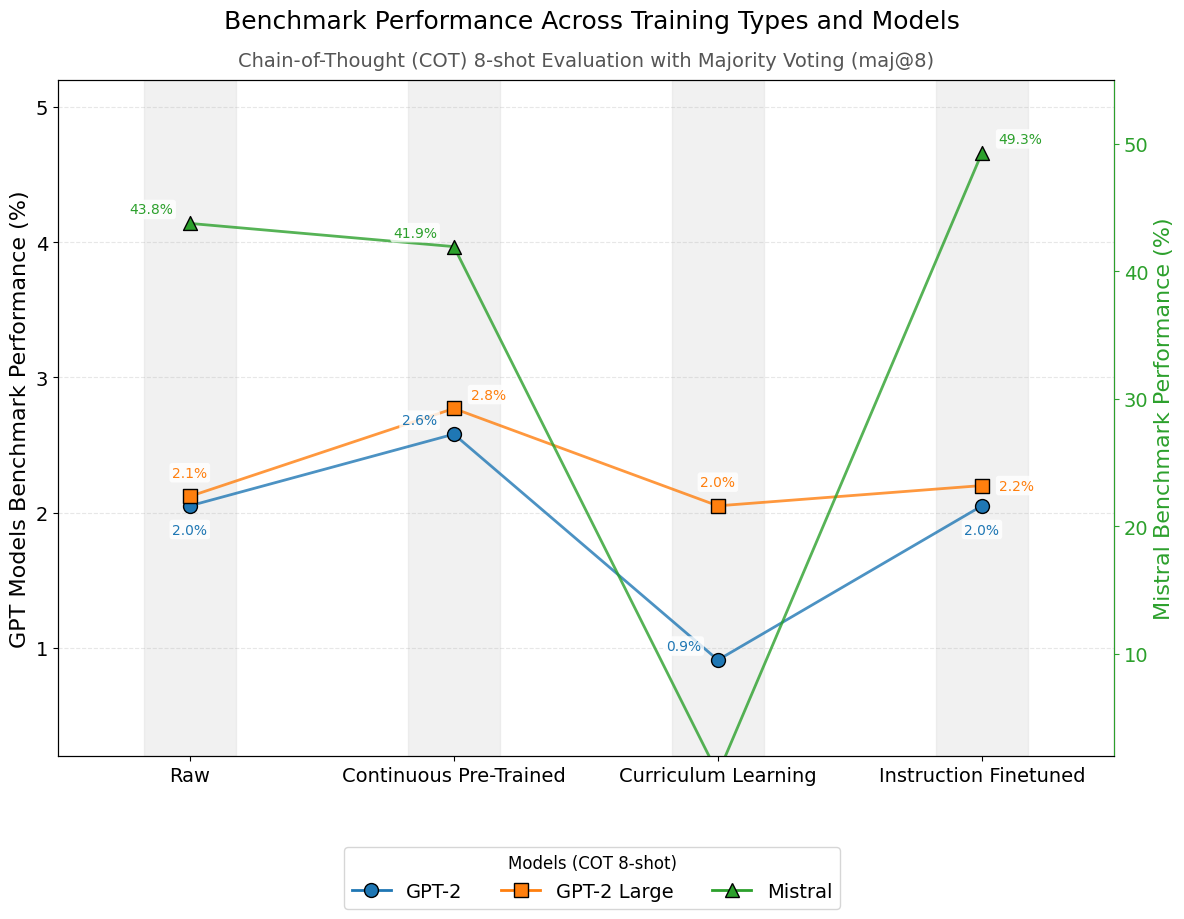

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Increase the default font sizes - making axis titles and labels even larger
plt.rcParams['font.size'] = 12  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16  # Increased from 14
plt.rcParams['xtick.labelsize'] = 14  # Increased from 12
plt.rcParams['ytick.labelsize'] = 14  # Increased from 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis
training_positions = {training: i+1 for i, training in enumerate(training_types)}

# Define colors and markers for models with better visual distinction
model_colors = {
    'GPT-2': '#1f77b4',         # Blue
    'GPT-2 Large': '#ff7f0e',   # Orange
    'Mistral': '#2ca02c'        # Green
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area - slightly taller for legend space at bottom
fig, ax_left = plt.subplots(figsize=(12, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = 'black'      # GPT models
right_color = '#2ca02c'   # Mistral - green

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color)
ax_left.spines['left'].set_color(left_color)
ax_right.tick_params(axis='y', colors=right_color)
ax_right.spines['right'].set_color(right_color)

# Create wider training "bars" instead of lines
bar_width = 0.35  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0.2), bar_width, 5, 
                              color='lightgray', alpha=0.3, zorder=0))

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get COT value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(cot)
            model_data[model]['training'].append(training)

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw connecting lines first (beneath points)
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=2, alpha=0.8, zorder=2)
    
    # Draw points
    ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=100, zorder=3, edgecolors='black', linewidth=1)
    
    # Add small labels for each data point with white background for better readability
    # Use predefined positions to avoid overlaps
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        
        # Custom positioning for each data point based on model and training type
        # to avoid overlaps without using external libraries
        if model == 'Mistral':
            if training == 'Raw':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5 
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
        elif model == 'GPT-2':
            if training == 'Raw':
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = -12, 5
                ha, va = 'right', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 0, -12
                ha, va = 'center', 'top'
        else:  # GPT-2 Large
            if training == 'Raw':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            elif training == 'Continuous Pre-Trained':
                offset_x, offset_y = 12, 5
                ha, va = 'left', 'bottom'
            elif training == 'Curriculum Learning':
                offset_x, offset_y = 0, 12
                ha, va = 'center', 'bottom'
            else:  # Instruction Finetuned
                offset_x, offset_y = 12, 0
                ha, va = 'left', 'center'
        
        # Create label with white background for better readability
        ax.annotate(
            f"{y:.1f}%", 
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords='offset points',
            ha=ha, va=va,
            fontsize=10,
            color=model_colors[model],
            bbox=dict(boxstyle="round,pad=0.2", fc='white', ec="none", alpha=0.8)
        )

# Set y-axis limits with some padding - raising the bottom limit above 0
ax_left.set_ylim(0.2, 5.2)      # GPT models scale starts higher
ax_right.set_ylim(2, 55)        # Mistral scale starts at 2 instead of 0

# Set x-axis labels
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(list(training_positions.keys()), fontsize=14, rotation=0, ha='center')
ax_left.set_xlim(0.5, len(training_types) + 0.5)  # Set x-axis limits with padding

# Set y-axis labels with increased font size
ax_left.set_ylabel('GPT Models Benchmark Performance (%)', fontsize=16, color=left_color)
ax_right.set_ylabel('Mistral Benchmark Performance (%)', fontsize=16, color=right_color)

# Create custom legend with both line and marker
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=10, linestyle='-', linewidth=2,
                      markerfacecolor=model_colors[model], markeredgecolor='black'))

# Add the legend at the bottom of the plot
fig.legend(handles=model_legend, 
          loc='upper center', bbox_to_anchor=(0.5, 0.06),
          ncol=len(models), fontsize=14, title="Models (COT 8-shot)")  # Increased legend font size

# Use the header & subheader structure from Code 1
plt.suptitle('Benchmark Performance Across Training Types and Models', 
             fontsize=18, y=0.98)
plt.title('Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting (maj@8)', 
          fontsize=14, pad=10, color='#555555')

# Add grid lines for readability
ax_left.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust layout - make more room at the bottom for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Save the plot
plt.savefig('benchmark_performance_final.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

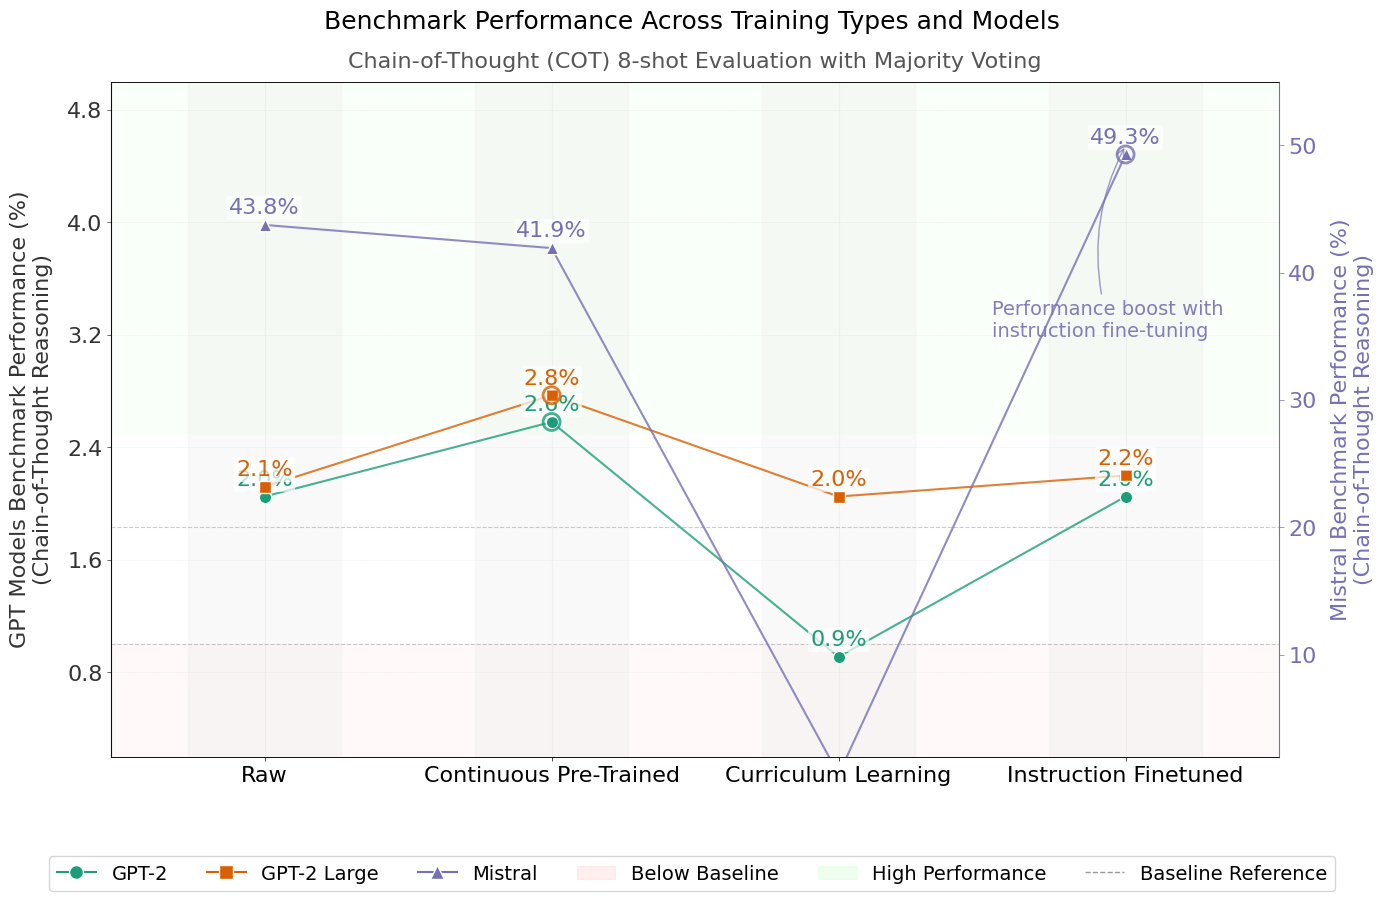

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

# Set colorblind-friendly palette (using a recommended set from ColorBrewer)
plt.rcParams['axes.prop_cycle'] = plt.cycler('color', 
                                             ['#1b9e77',  # teal
                                              '#d95f02',  # orange
                                              '#7570b3',  # purple/blue
                                              '#e7298a',  # pink
                                              '#66a61e',  # green
                                              '#e6ab02']) # yellow

# Increase the default font sizes
plt.rcParams['font.size'] = 12  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16  # Match axis labels
plt.rcParams['ytick.labelsize'] = 16  # Match axis labels
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 18

# Load the data from the Excel file
# Note: Update the path to your actual file location
df = pd.read_excel('/Users/mauricebaier/Documents/Master/4th_master_thesis/_code/math-reasoning-in-language-models/data/Performances.xlsx', engine='openpyxl')

# Ensure the columns are numeric
df['COT 8-shot maj1@8'] = pd.to_numeric(df['COT 8-shot maj1@8'], errors='coerce')

# Extract unique models and training types
models = df['Model'].unique()
training_types = df['Training Type'].unique()

# Define training type positions on x-axis with wider spacing
training_positions = {training: i*1.5+1 for i, training in enumerate(training_types)}

# Define colors and markers with a colorblind-friendly palette
model_colors = {
    'GPT-2': '#1b9e77',        # teal
    'GPT-2 Large': '#d95f02',  # orange
    'Mistral': '#7570b3'       # purple/blue
}

model_markers = {
    'GPT-2': 'o',         # Circle
    'GPT-2 Large': 's',   # Square
    'Mistral': '^'        # Triangle
}

# Create a figure with a single plot area
fig, ax_left = plt.subplots(figsize=(14, 9))

# Create a right y-axis for Mistral
ax_right = ax_left.twinx()

# Set colors for axes
left_color = '#333333'      # Dark gray for GPT models
right_color = '#7570b3'     # Purple/blue for Mistral

# Style the y-axes
ax_left.tick_params(axis='y', colors=left_color, width=0.5)
ax_left.spines['left'].set_color(left_color)
ax_left.spines['left'].set_linewidth(0.8)
ax_right.tick_params(axis='y', colors=right_color, width=0.5)
ax_right.spines['right'].set_color(right_color)
ax_right.spines['right'].set_linewidth(0.8)

# Clean up other spines
for spine in ['top', 'bottom', 'right']:
    ax_left.spines[spine].set_linewidth(0.5)
for spine in ['top', 'bottom', 'left']:
    ax_right.spines[spine].set_linewidth(0.5)

# Create vertical reference lines between training types
for x_pos in training_positions.values():
    ax_left.axvline(x=x_pos, color='lightgray', linestyle='-', linewidth=0.8, alpha=0.3, zorder=0)

# Create wider training "bars" instead of lines - starting from 0.2 instead of 0
bar_width = 0.8  # Width for bars
for training, x_pos in training_positions.items():
    # Draw wider "bars" for each training position with more subtle coloring
    ax_left.add_patch(plt.Rectangle((x_pos - bar_width/2, 0.2), bar_width, 5, 
                              color='#f0f0f0', alpha=0.4, zorder=0))

# Add baseline reference - adjusted to start at 0.2
ax_left.axhline(y=1.0, color='#999999', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)
ax_right.axhline(y=20.0, color='#999999', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)

# Prepare data for connecting lines between training types for the same model
model_data = {model: {'x': [], 'y': [], 'training': []} for model in models}

# First, collect all data points
for training, x_pos in training_positions.items():
    # For each model
    for model in models:
        # Get data for this model and training combination
        data_row = df[(df['Model'] == model) & (df['Training Type'] == training)]
        
        if not data_row.empty:
            # Get COT value
            cot = data_row['COT 8-shot maj1@8'].iloc[0]
            
            # Store x and y for connecting lines later
            model_data[model]['x'].append(x_pos)
            model_data[model]['y'].append(cot)
            model_data[model]['training'].append(training)

# Find highest performance points for each model
highest_points = {}
for model, data in model_data.items():
    if data['y']:  # Check if list is not empty
        max_idx = np.argmax(data['y'])
        highest_points[model] = (data['x'][max_idx], data['y'][max_idx])

# Plot data and connect lines for each model
for model, data in model_data.items():
    x_values = data['x']
    y_values = data['y']
    
    # Choose appropriate axis based on model type
    if model == 'Mistral':
        ax = ax_right
    else:
        ax = ax_left
    
    # Draw connecting lines with reduced thickness
    ax.plot(x_values, y_values, color=model_colors[model], linestyle='-', 
            linewidth=1.5, alpha=0.8, zorder=2)
    
    # Draw points with smaller size but higher contrast
    scatter = ax.scatter(x_values, y_values, 
              color=model_colors[model], marker=model_markers[model], 
              s=80, zorder=3, edgecolors='white', linewidth=1)
    
    # Add numeric labels near data points - use same size as axis titles (16pt)
    for i, (x, y) in enumerate(zip(x_values, y_values)):
        training = data['training'][i]
        if model == 'Mistral':
            ax.annotate(f"{y:.1f}%", 
                     xy=(x, y), 
                     xytext=(0, 5), 
                     textcoords='offset points',
                     ha='center', va='bottom',
                     fontsize=16, color=model_colors[model],
                     bbox=dict(boxstyle="round,pad=0.1", fc='white', ec="none", alpha=0.7))
        else:
            ax.annotate(f"{y:.1f}%", 
                     xy=(x, y), 
                     xytext=(0, 5), 
                     textcoords='offset points',
                     ha='center', va='bottom',
                     fontsize=16, color=model_colors[model],
                     bbox=dict(boxstyle="round,pad=0.1", fc='white', ec="none", alpha=0.7))

# Highlight the highest-performing model points
for model, (x, y) in highest_points.items():
    if model == 'Mistral':
        ax_right.scatter([x], [y], s=150, facecolors='none', edgecolors=model_colors[model], 
                      linewidth=2, alpha=0.8, zorder=4)
    else:
        ax_left.scatter([x], [y], s=150, facecolors='none', edgecolors=model_colors[model], 
                      linewidth=2, alpha=0.8, zorder=4)

# Add performance threshold regions with subtle shading - starting from 0.2
ax_left.axhspan(0.2, 1, alpha=0.1, color='#ffcccc', zorder=0)  # Poor performance zone
ax_left.axhspan(2.5, 5, alpha=0.1, color='#ccffcc', zorder=0)  # Good performance zone

# Set y-axis limits with some padding - starting y-axis at 0.2
ax_left.set_ylim(0.2, 5)       # GPT models scale (0.2-5%)
ax_right.set_ylim(2, 55)       # Mistral scale (2-55%)

# Have fewer ticks on the axes for cleaner look
ax_left.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax_right.yaxis.set_major_locator(MaxNLocator(nbins=6))

# Set x-axis labels and improve tick appearance - using same size as axis titles
ax_left.set_xticks(list(training_positions.values()))
ax_left.set_xticklabels(list(training_positions.keys()), fontsize=16, rotation=0, ha='center')
ax_left.set_xlim(min(training_positions.values())-0.8, max(training_positions.values())+0.8)
ax_left.tick_params(axis='x', which='both', width=0.5, length=3)
ax_left.tick_params(axis='y', which='both', width=0.5, length=3)

# Set more descriptive y-axis labels
ax_left.set_ylabel('GPT Models Benchmark Performance (%)\n(Chain-of-Thought Reasoning)', 
                  fontsize=16, color=left_color, labelpad=10)
ax_right.set_ylabel('Mistral Benchmark Performance (%)\n(Chain-of-Thought Reasoning)', 
                   fontsize=16, color=right_color, labelpad=10)

# Create custom legend with both line and marker, positioned at the bottom
model_legend = []
for model in models:
    model_legend.append(Line2D([0], [0], marker=model_markers[model], color=model_colors[model], 
                      label=model, markersize=10, linestyle='-', linewidth=1.5,
                      markerfacecolor=model_colors[model], markeredgecolor='white'))

# Add performance zones to legend
poor_patch = mpatches.Patch(color='#ffcccc', alpha=0.3, label='Below Baseline')
good_patch = mpatches.Patch(color='#ccffcc', alpha=0.3, label='High Performance')
baseline_line = Line2D([0], [0], color='#999999', lw=1, linestyle='--', label='Baseline Reference')

# Group legend items
gpt_legend = model_legend[:2]  # GPT models
mistral_legend = [model_legend[2]]  # Mistral
context_legend = [poor_patch, good_patch, baseline_line]  # Context items

# Create a figure-wide legend at the bottom with larger font size
fig.legend(handles=gpt_legend + mistral_legend + context_legend,
          loc='upper center', bbox_to_anchor=(0.5, 0.05),
          fancybox=True, shadow=False, ncol=6, fontsize=14)

# Add more comprehensive title and subtitle
plt.suptitle('Benchmark Performance Across Training Types and Models', 
             fontsize=18, y=0.98)
plt.title('Chain-of-Thought (COT) 8-shot Evaluation with Majority Voting', 
          fontsize=16, pad=10, color='#555555')

# Improve grid appearance
ax_left.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.3)

# Add subtle annotations to explain key trends - using larger font size
# For Mistral drop in Curriculum Learning
ax_right.annotate('Performance drop', 
                xy=(training_positions['Curriculum Learning'], 0.5), 
                xytext=(training_positions['Curriculum Learning']-0.5, 10),
                arrowprops=dict(arrowstyle='->',
                                color=model_colors['Mistral'],
                                alpha=0.7,
                                connectionstyle="arc3,rad=.2"),
                fontsize=14, color=model_colors['Mistral'], alpha=0.9)

# For dramatic performance boost with instruction fine-tuning
ax_right.annotate('Performance boost with\ninstruction fine-tuning', 
                xy=(training_positions['Instruction Finetuned'], 50), 
                xytext=(training_positions['Instruction Finetuned']-0.7, 35),
                arrowprops=dict(arrowstyle='->',
                                color=model_colors['Mistral'],
                                alpha=0.7,
                                connectionstyle="arc3,rad=-.2"),
                fontsize=14, color=model_colors['Mistral'], alpha=0.9)

# Adjust figure layout with more bottom space for legend
fig.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Save the plot
plt.savefig('benchmark_performance_final.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()